<a href="https://colab.research.google.com/github/sschares/ores5160-2026/blob/main/Schares_ORES5160_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [195]:
import json
from urllib.request import urlopen, Request

req = Request("https://data.cdc.gov/resource/8xy9-ubqz.json", headers={'User-Agent': 'Mozilla/5.0'})

with urlopen(req) as response:
  source = response.read()

  print(source)

b'[{"round":"1","indicator":"Provider offers telemedicine","group":"Total","subgroup":"Total","sample_size":"6786","response":"Total","percent":"100"}\n,{"round":"1","indicator":"Provider offers telemedicine","group":"Total","subgroup":"Total","response":"Yes","percent":"36.6","standard_error":"0.8"}\n,{"round":"1","indicator":"Provider offers telemedicine","group":"Total","subgroup":"Total","response":"No","percent":"46.9","standard_error":"0.8"}\n,{"round":"1","indicator":"Provider offers telemedicine","group":"Total","subgroup":"Total","response":"Do not know","percent":"5.2","standard_error":"0.4"}\n,{"round":"1","indicator":"Provider offers telemedicine","group":"Total","subgroup":"Total","response":"No usual place of care","percent":"11.3","standard_error":"0.7"}\n,{"round":"1","indicator":"Provider offers telemedicine","group":"Age group","subgroup":"18-44 years","sample_size":"2607","response":"Total","percent":"100"}\n,{"round":"1","indicator":"Provider offers telemedicine","g

In [196]:
data = json.loads(source)
print(type(data))

<class 'list'>


In [197]:
print(json.dumps(data, indent = 2))

[
  {
    "round": "1",
    "indicator": "Provider offers telemedicine",
    "group": "Total",
    "subgroup": "Total",
    "sample_size": "6786",
    "response": "Total",
    "percent": "100"
  },
  {
    "round": "1",
    "indicator": "Provider offers telemedicine",
    "group": "Total",
    "subgroup": "Total",
    "response": "Yes",
    "percent": "36.6",
    "standard_error": "0.8"
  },
  {
    "round": "1",
    "indicator": "Provider offers telemedicine",
    "group": "Total",
    "subgroup": "Total",
    "response": "No",
    "percent": "46.9",
    "standard_error": "0.8"
  },
  {
    "round": "1",
    "indicator": "Provider offers telemedicine",
    "group": "Total",
    "subgroup": "Total",
    "response": "Do not know",
    "percent": "5.2",
    "standard_error": "0.4"
  },
  {
    "round": "1",
    "indicator": "Provider offers telemedicine",
    "group": "Total",
    "subgroup": "Total",
    "response": "No usual place of care",
    "percent": "11.3",
    "standard_error": 

In [198]:
import pandas as pd
import numpy as np

telemed = pd.DataFrame(data)

In [199]:
telemed.head()

,round,indicator,group,subgroup,sample_size,response,percent,standard_error,suppression,significant_1,significant_2
0,1,Provider offers telemedicine,Total,Total,6786,Total,100,NaN,NaN,NaN,NaN
1,1,Provider offers telemedicine,Total,Total,NaN,Yes,36.6,0.8,NaN,NaN,NaN
2,1,Provider offers telemedicine,Total,Total,NaN,No,46.9,0.8,NaN,NaN,NaN
3,1,Provider offers telemedicine,Total,Total,NaN,Do not know,5.2,0.4,NaN,NaN,NaN
4,1,Provider offers telemedicine,Total,Total,NaN,No usual place of care,11.3,0.7,NaN,NaN,NaN


In [200]:
print("Original columns:", telemed.columns.tolist())

# Rename the 'round' column to 'date_range_category'
telemed = telemed.rename(columns={'round': 'date_range_category'})

Original columns: ['round', 'indicator', 'group', 'subgroup', 'sample_size', 'response', 'percent', 'standard_error', 'suppression', 'significant_1', 'significant_2']


In [201]:
print("Updated columns:", telemed.columns.tolist())
display(telemed.head())

Updated columns: ['date_range_category', 'indicator', 'group', 'subgroup', 'sample_size', 'response', 'percent', 'standard_error', 'suppression', 'significant_1', 'significant_2']


,date_range_category,indicator,group,subgroup,sample_size,response,percent,standard_error,suppression,significant_1,significant_2
0,1,Provider offers telemedicine,Total,Total,6786,Total,100,NaN,NaN,NaN,NaN
1,1,Provider offers telemedicine,Total,Total,NaN,Yes,36.6,0.8,NaN,NaN,NaN
2,1,Provider offers telemedicine,Total,Total,NaN,No,46.9,0.8,NaN,NaN,NaN
3,1,Provider offers telemedicine,Total,Total,NaN,Do not know,5.2,0.4,NaN,NaN,NaN
4,1,Provider offers telemedicine,Total,Total,NaN,No usual place of care,11.3,0.7,NaN,NaN,NaN


In [202]:
#Drop last 4 columns
telemed = telemed.iloc[:, :-4]

In [203]:
#Drop sample_size
telemed = telemed.drop(columns=['sample_size'])
display(telemed.head())
telemed.to_csv('telemedicine.csv', index=False)

,date_range_category,indicator,group,subgroup,response,percent
0,1,Provider offers telemedicine,Total,Total,Total,100
1,1,Provider offers telemedicine,Total,Total,Yes,36.6
2,1,Provider offers telemedicine,Total,Total,No,46.9
3,1,Provider offers telemedicine,Total,Total,Do not know,5.2
4,1,Provider offers telemedicine,Total,Total,No usual place of care,11.3


In [204]:
telemed_no = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'No'][telemed['subgroup'] == 'Total']
display(telemed_no.head())

/tmp/ipykernel_14483/3647151284.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  telemed_no = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'No'][telemed['subgroup'] == 'Total']
/tmp/ipykernel_14483/3647151284.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  telemed_no = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'No'][telemed['subgroup'] == 'Total']


,date_range_category,indicator,group,subgroup,response,percent
2,1,Provider offers telemedicine,Total,Total,No,46.9
97,2,Provider offers telemedicine,Total,Total,No,48
192,3,Provider offers telemedicine,Total,Total,No,54.1


In [205]:
#Recreate telemed_no table with date ranges in place of categories
define_date_range = {
    '1': '2020-06-09 to 2020-07-06',
    '2': '2020-08-03 to 2020-08-20',
    '3': '2021-05-17 to 2021-06-30'}

telemed_no['date_range_category'] = telemed_no['date_range_category'].map(define_date_range)
display(telemed_no.head())


,date_range_category,indicator,group,subgroup,response,percent
2,2020-06-09 to 2020-07-06,Provider offers telemedicine,Total,Total,No,46.9
97,2020-08-03 to 2020-08-20,Provider offers telemedicine,Total,Total,No,48
192,2021-05-17 to 2021-06-30,Provider offers telemedicine,Total,Total,No,54.1


In [206]:
telemed_yes = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'Yes'][telemed['subgroup'] == 'Total']
display(telemed_yes.head())


/tmp/ipykernel_14483/417946074.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  telemed_yes = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'Yes'][telemed['subgroup'] == 'Total']
/tmp/ipykernel_14483/417946074.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  telemed_yes = telemed[telemed['indicator'] == 'Provider offers telemedicine'][telemed['response'] == 'Yes'][telemed['subgroup'] == 'Total']


,date_range_category,indicator,group,subgroup,response,percent
1,1,Provider offers telemedicine,Total,Total,Yes,36.6
96,2,Provider offers telemedicine,Total,Total,Yes,37.1
191,3,Provider offers telemedicine,Total,Total,Yes,31.7


In [207]:
#Recreate telemed_yes table with date ranges in place of categories
define_date_range = {
    '1': '2020-06-09 to 2020-07-06',
    '2': '2020-08-03 to 2020-08-20',
    '3': '2021-05-17 to 2021-06-30'}

telemed_yes['date_range_category'] = telemed_yes['date_range_category'].map(define_date_range)
display(telemed_yes.head())

,date_range_category,indicator,group,subgroup,response,percent
1,2020-06-09 to 2020-07-06,Provider offers telemedicine,Total,Total,Yes,36.6
96,2020-08-03 to 2020-08-20,Provider offers telemedicine,Total,Total,Yes,37.1
191,2021-05-17 to 2021-06-30,Provider offers telemedicine,Total,Total,Yes,31.7


In [208]:
telemed.describe(include="all")

,date_range_category,indicator,group,subgroup,response,percent
count,798,798,798,798,798,775
unique,3,3,7,19,6,370
top,1,Provider offers telemedicine,Race/Hispanic origin,Total,Total,100
freq,266,285,168,42,171,171


In [209]:
telemed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   date_range_category  798 non-null    object
 1   indicator            798 non-null    object
 2   group                798 non-null    object
 3   subgroup             798 non-null    object
 4   response             798 non-null    object
 5   percent              775 non-null    object
dtypes: object(6)
memory usage: 37.5+ KB


In [210]:
telemed = telemed.replace(r'^\s*$', np.nan, regex=True)
telemed.isnull().sum()

,0
date_range_category,0
indicator,0
group,0
subgroup,0
response,0
percent,23


In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [212]:
#Load Google Symptom Search Data
df1 = pd.read_csv('/content/drive/MyDrive/bq-results-20260425-185741-1777143487579/bq-results-20260425-185741-1777143487579.csv')
df1.head()

,country_region,date,symptom,value,date_range_category
0,United States,2020-07-02,symptom_dry_eye_syndrome,0.59,1.0
1,United States,2020-07-04,symptom_insomnia,2.60,1.0
2,United States,2020-06-23,symptom_ear_pain,0.68,1.0
3,United States,2020-06-23,symptom_heartburn,2.77,1.0
4,United States,2020-06-09,symptom_pneumonia,0.72,1.0


In [213]:
#Describe Google Symptom Search Data
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222956 entries, 0 to 1222955
Data columns (total 5 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   country_region       1222956 non-null  object 
 1   date                 1222956 non-null  object 
 2   symptom              1222956 non-null  object 
 3   value                1222956 non-null  float64
 4   date_range_category  37136 non-null    float64
dtypes: float64(2), object(3)
memory usage: 46.7+ MB


In [214]:
#Convert date in Google Symptom Search Data to datetime
df1['date'] = pd.to_datetime(df1['date'])

In [215]:
#Describe Google Symptom Search Data
df1.describe(include="all")

,country_region,date,symptom,value,date_range_category
count,1222956,1222956,1222956,1.222956e+06,37136.000000
unique,1,NaN,422,NaN,NaN
top,United States,NaN,symptom_lightheadedness,NaN,NaN
freq,1222956,NaN,2898,NaN,NaN
mean,NaN,2021-11-10 11:59:59.999999744,NaN,1.023258e+00,2.193182
min,NaN,2017-11-23 00:00:00,NaN,1.000000e-02,1.000000
25%,NaN,2019-11-17 00:00:00,NaN,1.600000e-01,1.000000
50%,NaN,2021-11-10 12:00:00,NaN,3.500000e-01,2.500000
75%,NaN,2023-11-05 00:00:00,NaN,9.000000e-01,3.000000
max,NaN,2025-10-29 00:00:00,NaN,1.033500e+02,3.000000


In [216]:
# Add column "Year" to Google Symptom Search Data
df1["year"] = df1["date"].dt.year

In [217]:
# Create pivot table to calculate Google symptom searches by year
df1.pivot_table(index='year', columns='symptom', values='value', aggfunc='sum')

symptom,symptom_abdominal_obesity,symptom_abdominal_pain,symptom_acne,symptom_actinic_keratosis,symptom_acute_bronchitis,symptom_adrenal_crisis,symptom_ageusia,symptom_alcoholism,symptom_allergic_conjunctivitis,symptom_allergy,...,symptom_visual_acuity,symptom_vomiting,symptom_wart,symptom_water_retention,symptom_weakness,symptom_weight_gain,symptom_wheeze,symptom_xeroderma,symptom_xerostomia,symptom_yawn
year,,,,,,,,,,,,,,,,,,,,,
2017,63.17,153.71,269.31,8.89,24.44,3.45,1.38,149.43,1.84,317.74,...,6.63,111.19,46.54,8.31,12.05,97.51,9.32,90.81,12.88,5.26
2018,741.42,1398.27,2675.44,106.17,151.25,33.83,12.52,1359.82,23.17,3372.66,...,64.55,892.87,483.55,95.88,129.11,1019.43,77.43,719.95,122.99,49.37
2019,750.42,1499.87,2881.50,115.76,167.43,35.51,14.08,1460.51,25.87,3730.46,...,73.66,991.47,496.38,103.92,138.66,1075.48,89.43,794.42,136.89,55.87
2020,844.98,1466.46,3048.13,112.93,120.02,41.32,52.19,1417.97,23.26,3813.82,...,76.11,898.95,458.04,98.09,141.73,1083.67,94.05,946.98,146.63,60.37
2021,769.71,1534.71,2726.26,118.90,121.50,38.96,56.02,1424.24,23.23,4041.63,...,74.50,981.81,453.45,101.11,144.66,1114.54,89.10,821.23,146.56,58.00
2022,664.34,1588.89,2494.82,130.02,159.96,37.92,29.81,1407.10,26.88,4112.41,...,76.54,1054.25,439.49,96.83,145.99,1060.52,95.81,819.58,148.40,56.25
2023,610.00,1645.98,2579.42,128.23,164.36,42.32,19.66,1389.31,32.86,4207.95,...,74.70,1081.80,456.95,95.80,141.79,1047.91,97.76,822.24,152.85,57.02
2024,548.96,1564.02,2533.15,121.46,157.83,52.41,17.49,1358.77,30.13,4127.23,...,71.70,1049.10,433.34,89.89,130.79,954.68,92.16,796.57,153.87,52.86
2025,484.45,1313.12,2093.54,107.83,116.40,37.98,13.99,1068.32,24.40,3594.42,...,60.91,942.66,383.64,83.68,112.97,821.75,74.09,639.28,131.72,46.79


In [218]:
from pandas.core import groupby
df1.groupby("symptom")["value"].sum()
orderby = df1.groupby("symptom")["value"].sum().sort_values(ascending=False)
orderby

,value
symptom,
symptom_pain,95798.05
symptom_infection,61055.91
symptom_allergy,31318.32
symptom_common_cold,28282.70
symptom_diabetes,23729.56
...,...
symptom_angular_cheilitis,200.62
symptom_crackles,199.80
symptom_polydipsia,181.19


Text(0, 0.5, 'Frequency')

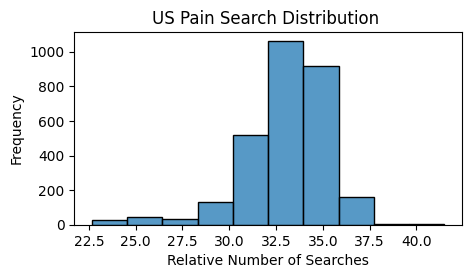

In [219]:
plt.figure(figsize=(5, 2.5))
sns.histplot(df1[
    (df1['symptom'] == "symptom_pain")]['value'], bins=10)
plt.title('US Pain Search Distribution ')
plt.xlabel('Relative Number of Searches')
plt.ylabel('Frequency')



Text(0, 0.5, 'Relative Frequency of Searches')

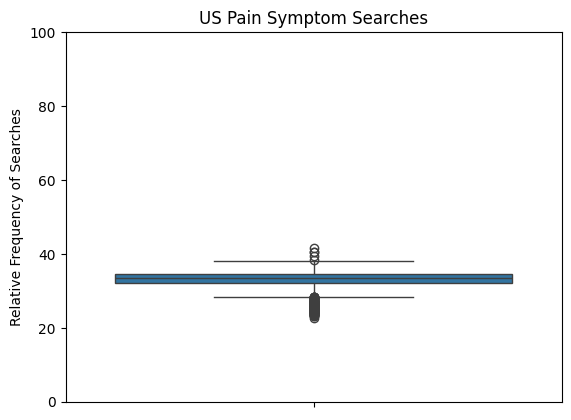

In [220]:
sns.boxplot(df1[
    (df1['symptom'] == "symptom_pain")]['value'])
plt.ylim(0, 100)
plt.title('US Pain Symptom Searches')
plt.ylabel('Relative Frequency of Searches')

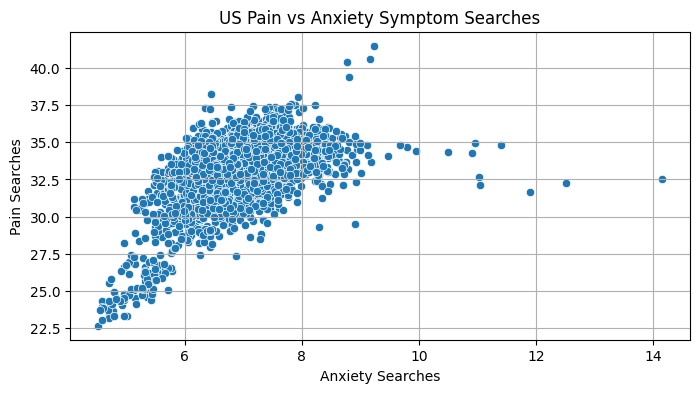

In [221]:
pain_data = df1[(df1['symptom'] == 'symptom_pain')][['date', 'value']].rename(columns={'value': 'Pain_Searches'})
anxiety_data= df1[(df1['symptom'] == 'symptom_anxiety')][['date', 'value']].rename(columns={'value': 'Anxiety_Searches'})

merged_data = pd.merge(pain_data, anxiety_data, on='date', how='inner')

plt.figure(figsize=(8, 4))
sns.scatterplot(data=merged_data, x='Anxiety_Searches', y='Pain_Searches')
plt.title('US Pain vs Anxiety Symptom Searches')
plt.xlabel('Anxiety Searches')
plt.ylabel('Pain Searches')
plt.grid(True)
plt.show()

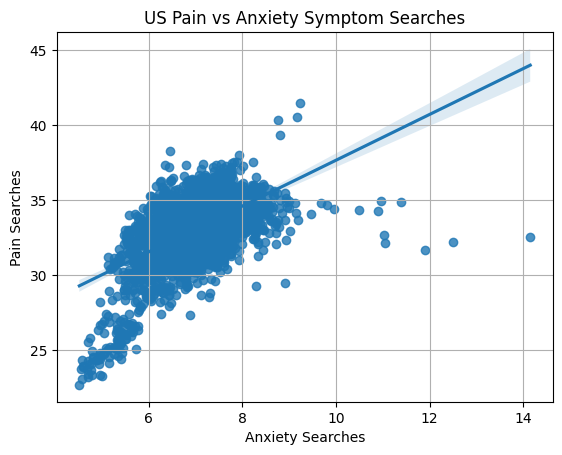

In [222]:
import statsmodels.api as sm
pain_data = df1[(df1['symptom'] == 'symptom_pain')][['date', 'value']].rename(columns={'value': 'Pain_Searches'})
anxiety_data= df1[(df1['symptom'] == 'symptom_anxiety')][['date', 'value']].rename(columns={'value': 'Anxiety_Searches'})

merged_data = pd.merge(pain_data, anxiety_data, on='date', how='inner')
sns.regplot(data=merged_data, x='Anxiety_Searches', y='Pain_Searches')
plt.title('US Pain vs Anxiety Symptom Searches')
plt.xlabel('Anxiety Searches')
plt.ylabel('Pain Searches')
plt.grid(True)
plt.show()

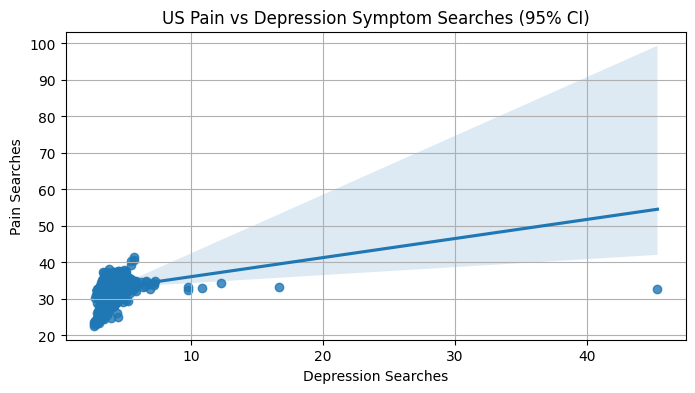

In [223]:
pain_data = df1[(df1['symptom'] == 'symptom_pain')][['date', 'value']].rename(columns={'value': 'Pain_Searches'})
depression_data= df1[(df1['symptom'] == 'symptom_depression')][['date', 'value']].rename(columns={'value': 'Depression_Searches'})

merged_data = pd.merge(pain_data, depression_data, on='date', how='inner')

plt.figure(figsize=(8, 4))
sns.regplot(data=merged_data, x='Depression_Searches', y='Pain_Searches', ci=95)
plt.title('US Pain vs Depression Symptom Searches (95% CI)')
plt.xlabel('Depression Searches')
plt.ylabel('Pain Searches')
plt.grid(True)
plt.show()



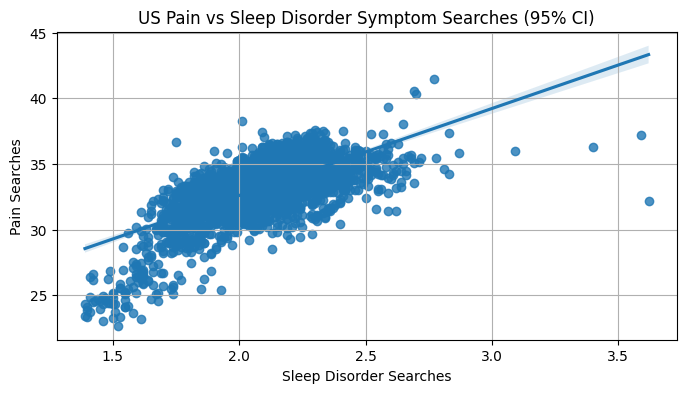

In [224]:
pain_data = df1[(df1['symptom'] == 'symptom_pain')][['date', 'value']].rename(columns={'value': 'Pain_Searches'})
sleep_disorder_data= df1[(df1['symptom'] == 'symptom_sleep_disorder')][['date', 'value']].rename(columns={'value': 'Sleep_Disorder_Searches'})

merged_data = pd.merge(pain_data, sleep_disorder_data, on='date', how='inner')

plt.figure(figsize=(8, 4))
sns.regplot(data=merged_data, x='Sleep_Disorder_Searches', y='Pain_Searches', ci=95)
plt.title('US Pain vs Sleep Disorder Symptom Searches (95% CI)')
plt.xlabel('Sleep Disorder Searches')
plt.ylabel('Pain Searches')
plt.grid(True)
plt.show()

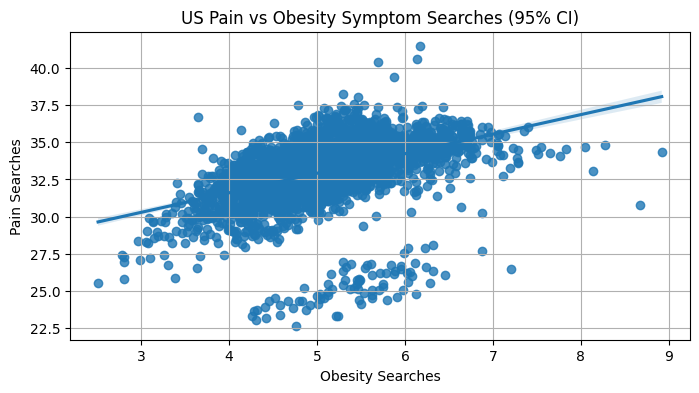

In [225]:
pain_data = df1[(df1['symptom'] == 'symptom_pain')][['date', 'value']].rename(columns={'value': 'Pain_Searches'})
obesity_data= df1[(df1['symptom'] == 'symptom_obesity')][['date', 'value']].rename(columns={'value': 'Obesity_Searches'})

merged_data = pd.merge(pain_data, obesity_data, on='date', how='inner')

plt.figure(figsize=(8, 4))
sns.regplot(data=merged_data, x='Obesity_Searches', y='Pain_Searches', ci=95)
plt.title('US Pain vs Obesity Symptom Searches (95% CI)')
plt.xlabel('Obesity Searches')
plt.ylabel('Pain Searches')
plt.grid(True)
plt.show()

In [226]:
symptom_sums = df1[df1['date_range_category'] != 'nan'].groupby(["date_range_category", "symptom"])["value"].sum()
max_searches_by_category = symptom_sums.groupby(level='date_range_category').idxmax()
result = symptom_sums.loc[max_searches_by_category]
display(result)

,,value
date_range_category,symptom,
1.0,symptom_pain,922.05
2.0,symptom_pain,575.59
3.0,symptom_pain,1540.91


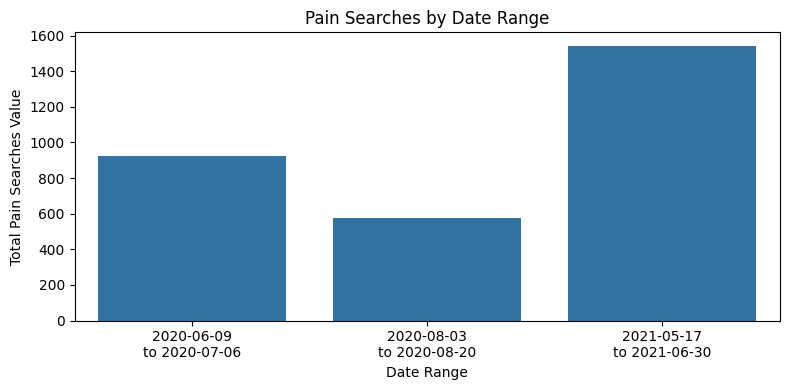

In [227]:
#Graph pain searches by category
pain_searches_by_category = df1[df1['symptom'] == "symptom_pain"].groupby('date_range_category')['value'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=pain_searches_by_category, x='date_range_category', y='value')
plt.title('Pain Searches by Date Range')
plt.xlabel('Date Range')
plt.ylabel('Total Pain Searches Value')

# Define the mapping for date ranges with newlines for wrapping
date_range_labels = {
    '1.0': '2020-06-09\nto 2020-07-06',
    '2.0': '2020-08-03\nto 2020-08-20',
    '3.0': '2021-05-17\nto 2021-06-30'
}

# Convert date_range_category to string for proper mapping
pain_searches_by_category['date_range_category'] = pain_searches_by_category['date_range_category'].astype(str)

# Apply the mapping to the x-axis tick labels, removing rotation for horizontal alignment
plt.xticks(ticks=range(len(pain_searches_by_category['date_range_category'])),
           labels=[date_range_labels.get(cat, cat) for cat in pain_searches_by_category['date_range_category']])

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

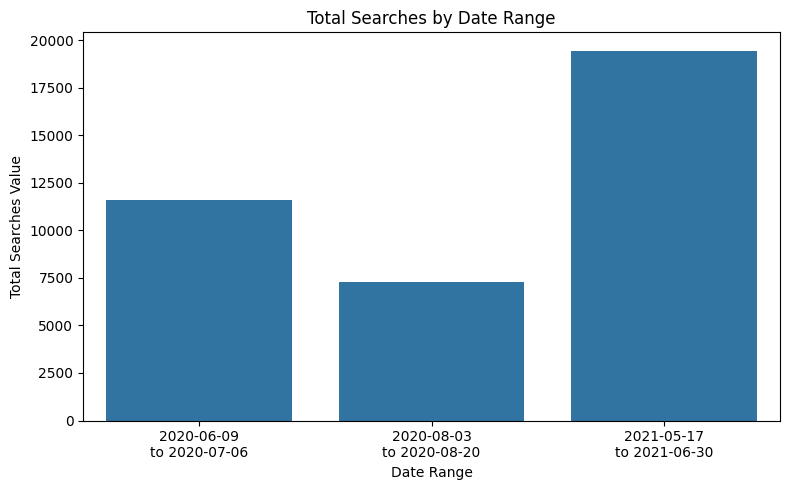

In [239]:
#Graph total Google symptom searches by date category
total_searches_by_category = df1.groupby('date_range_category')['value'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=total_searches_by_category, x='date_range_category', y='value')
plt.title('Total Searches by Date Range')
plt.xlabel('Date Range')
plt.ylabel('Total Searches Value')

# Define the mapping for date ranges with newlines for wrapping
date_range_labels = {
    '1.0': '2020-06-09\nto 2020-07-06',
    '2.0': '2020-08-03\nto 2020-08-20',
    '3.0': '2021-05-17\nto 2021-06-30'
}
# Convert date_range_category to string for proper mapping
total_searches_by_category['date_range_category'] = total_searches_by_category['date_range_category'].astype(str)

# Apply the mapping to the x-axis tick labels, removing rotation for horizontal alignment
plt.xticks(ticks=range(len(total_searches_by_category['date_range_category'])),
           labels=[date_range_labels.get(cat, cat) for cat in total_searches_by_category['date_range_category']])

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [229]:
df2 = pd.read_csv('/content/drive/MyDrive/bq-results-20260425-132419-1777124125607/bq-results-20260425-132419-1777124125607.csv')
df2.head()

,indicator,group,subgroup,response,percent,country_region,date,symptom,value,date_range_category
0,Provider offers telemedicine,Total,Total,Do not know,5.2,United States,2020-06-09,symptom_blurred_vision,0.36,1
1,Provider offers telemedicine,Total,Total,Do not know,5.2,United States,2020-06-09,symptom_granuloma,0.15,1
2,Provider offers telemedicine,Total,Total,Do not know,5.2,United States,2020-06-09,symptom_indigestion,1.35,1
3,Provider offers telemedicine,Total,Total,Do not know,5.2,United States,2020-06-09,symptom_throat_irritation,0.14,1
4,Provider offers telemedicine,Total,Total,Do not know,5.2,United States,2020-06-09,symptom_sleep_disorder,2.14,1


In [230]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408496 entries, 0 to 408495
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   indicator            408496 non-null  object 
 1   group                408496 non-null  object 
 2   subgroup             408496 non-null  object 
 3   response             408496 non-null  object 
 4   percent              408496 non-null  float64
 5   country_region       408496 non-null  object 
 6   date                 408496 non-null  object 
 7   symptom              408496 non-null  object 
 8   value                408496 non-null  float64
 9   date_range_category  408496 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 31.2+ MB


In [231]:
df2.describe(include="all")

,indicator,group,subgroup,response,percent,country_region,date,symptom,value,date_range_category
count,408496,408496,408496,408496,408496.000000,408496,408496,408496,408496.000000,408496.000000
unique,3,1,1,5,NaN,1,88,422,NaN,NaN
top,Provider offers telemedicine,Total,Total,Yes,NaN,United States,2020-06-09,symptom_hepatic_encephalopathy,NaN,NaN
freq,148544,408496,408496,111408,NaN,408496,4642,968,NaN,NaN
mean,NaN,NaN,NaN,NaN,27.263636,NaN,NaN,NaN,1.031506,2.193182
std,NaN,NaN,NaN,NaN,19.608575,NaN,NaN,NaN,2.377703,0.877212
min,NaN,NaN,NaN,NaN,3.900000,NaN,NaN,NaN,0.020000,1.000000
25%,NaN,NaN,NaN,NaN,11.300000,NaN,NaN,NaN,0.160000,1.000000
50%,NaN,NaN,NaN,NaN,18.700000,NaN,NaN,NaN,0.360000,2.500000
75%,NaN,NaN,NaN,NaN,46.900000,NaN,NaN,NaN,0.910000,3.000000


In [232]:
df2 = df2.replace(r'^\s*$', np.nan, regex=True)
df2.isnull().sum()

,0
indicator,0
group,0
subgroup,0
response,0
percent,0
country_region,0
date,0
symptom,0
value,0
date_range_category,0


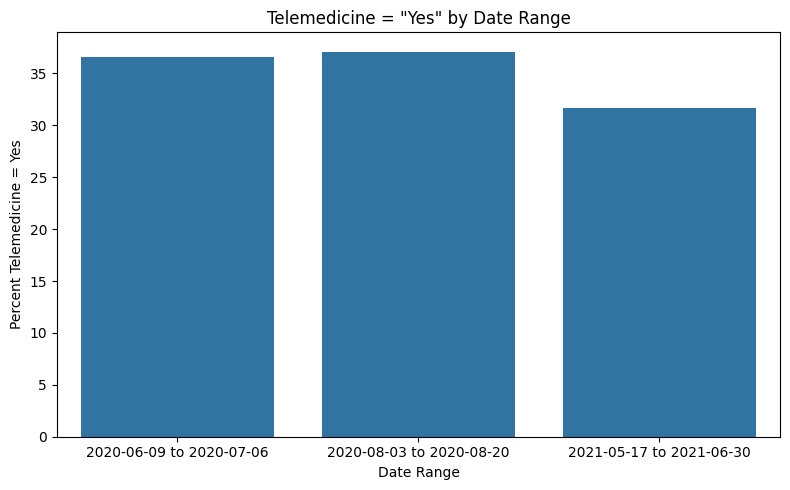

In [238]:
telemed_yes['percent'] = pd.to_numeric(telemed_yes['percent'], errors='coerce')

plt.figure(figsize=(8, 5))
sns.barplot(data=telemed_yes, x='date_range_category', y='percent')
plt.title('Telemedicine = "Yes" by Date Range')
plt.xlabel('Date Range')
plt.ylabel('Percent Telemedicine = Yes')

plt.tight_layout() # Adjust layout to prevent labels from being cut off

In [234]:
telemed_no_data = telemed[
    (telemed['indicator'] == 'Provider offers telemedicine') &
    (telemed['response'] == 'No') &
    (telemed['subgroup'] == 'Total')
].copy()

telemed_no_data['percent'] = pd.to_numeric(telemed_no_data['percent'], errors='coerce')
telemed_no_data['date_range_category'] = pd.to_numeric(telemed_no_data['date_range_category'])

pain_searches_by_category = df2[
    (df2['symptom'] == 'symptom_pain') &
    (df2['indicator'] == 'Provider offers telemedicine') &
    (df2['subgroup'] == 'Total') &
    (df2['response'] == 'No')
].groupby('date_range_category')['value'].sum().reset_index()

merged_data_no = pd.merge(telemed_no_data, pain_searches_by_category, on='date_range_category', how='inner')
display(merged_data_no.head())

,date_range_category,indicator,group,subgroup,response,percent,value
0,1,Provider offers telemedicine,Total,Total,No,46.9,922.05
1,2,Provider offers telemedicine,Total,Total,No,48.0,575.59
2,3,Provider offers telemedicine,Total,Total,No,54.1,1540.91


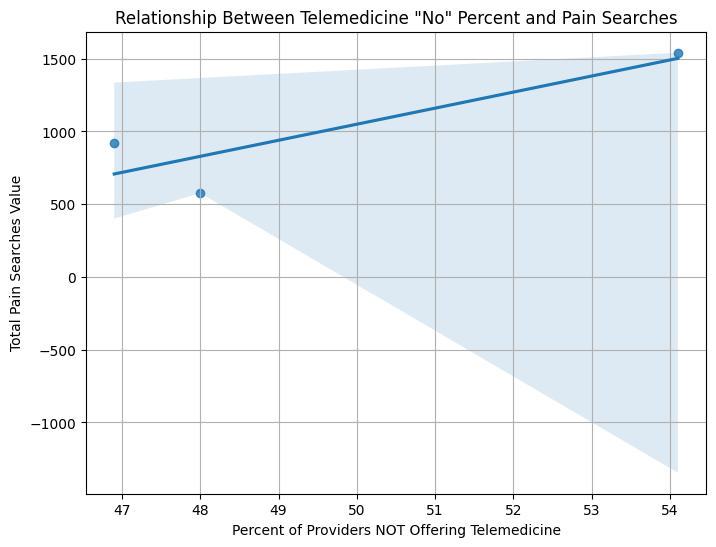

In [240]:
plt.figure(figsize=(8, 6))
sns.regplot(data=merged_data_no, x='percent', y='value', ci=95)
plt.title('Relationship Between Telemedicine "No" Percent and Pain Searches')
plt.xlabel('Percent of Providers NOT Offering Telemedicine')
plt.ylabel('Total Pain Searches Value')
plt.grid(True)
plt.show()

In [236]:
telemed_yes_data = telemed[
    (telemed['indicator'] == 'Provider offers telemedicine') &
    (telemed['response'] == 'Yes') &
    (telemed['subgroup'] == 'Total')
].copy()

telemed_yes_data['percent'] = pd.to_numeric(telemed_yes_data['percent'], errors='coerce')
telemed_yes_data['date_range_category'] = pd.to_numeric(telemed_yes_data['date_range_category'])

pain_searches_by_category = df2[
    (df2['symptom'] == 'symptom_pain') &
    (df2['indicator'] == 'Provider offers telemedicine') &
    (df2['subgroup'] == 'Total') &
    (df2['response'] == 'Yes')
].groupby('date_range_category')['value'].sum().reset_index()

merged_data_yes = pd.merge(telemed_yes_data, pain_searches_by_category, on='date_range_category', how='inner')
display(merged_data_yes.head())

,date_range_category,indicator,group,subgroup,response,percent,value
0,1,Provider offers telemedicine,Total,Total,Yes,36.6,922.05
1,2,Provider offers telemedicine,Total,Total,Yes,37.1,575.59
2,3,Provider offers telemedicine,Total,Total,Yes,31.7,1540.91


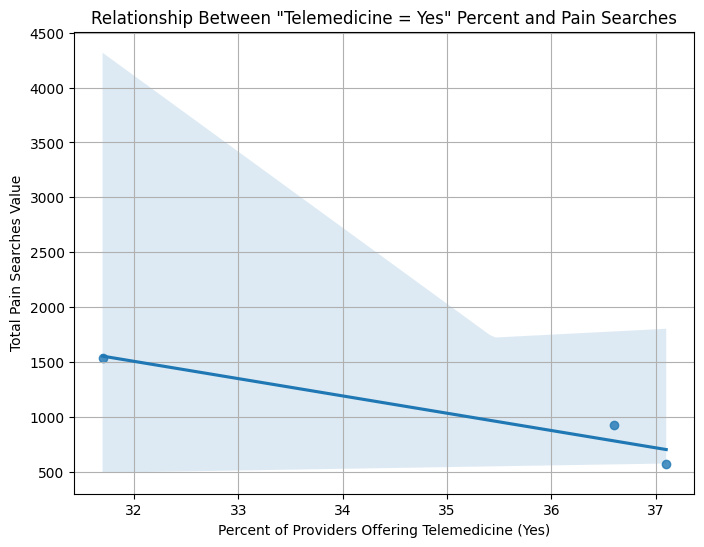

In [237]:
plt.figure(figsize=(8, 6))
sns.regplot(data=merged_data_yes, x='percent', y='value', ci=95)
plt.title('Relationship Between "Telemedicine = Yes" Percent and Pain Searches')
plt.xlabel('Percent of Providers Offering Telemedicine (Yes)')
plt.ylabel('Total Pain Searches Value')
plt.grid(True)
plt.show()